# Estudio dqdv y ajustes sobre ARBIN-NMC04


In [47]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl


✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [48]:
import numpy as np
import pandas as pd
from importlib import reload
from datetime import datetime, timedelta, timezone

In [49]:
# --- carga de datos ---
nombre_dataset = 'arbin-NMC04'
path_json = f"../tmp/{nombre_dataset}.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())


Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 16


## Gráficos para observar dataset

In [50]:
reload(pr)
reload(pl)
reload(utl)

<module 'utils_deriv' from '/home/mariajose/proc-icdv/src/utils_deriv.py'>

In [59]:
# --- Selección de ciclos ---
ciclos_sel_todos = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    #rango=(21, 900),
    excluir={list(dict_ciclos_sep.keys())[0], max(dict_ciclos_sep.keys()), list(dict_ciclos_sep.keys())[-2]}, # excluyo el primero, último y penúltimo
    #excluir={list(dict_ciclos_sep.keys())[0], max(dict_ciclos_sep.keys())}, # excluyo el primero y el último
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 13 ciclos seleccionados
   → [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


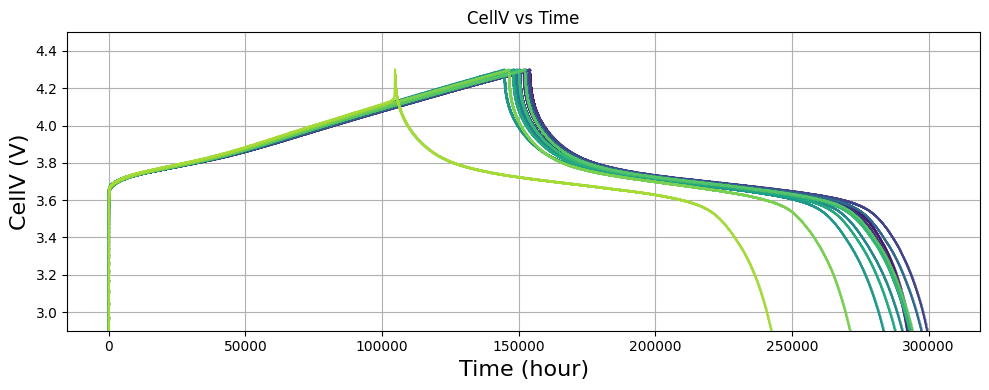

In [60]:
ciclos_sel_grafico = [ciclos_sel_todos[i] for i in range(len(ciclos_sel_todos))] #if i == 0]
pl.plot_n_cycles_tvsV(ciclos_sel_grafico, dict_ciclos_sep, nombre_dataset, Path('../tmp'))

La capacidad máxima es 23160.416 mAh y se alcanza en el ciclo 2.


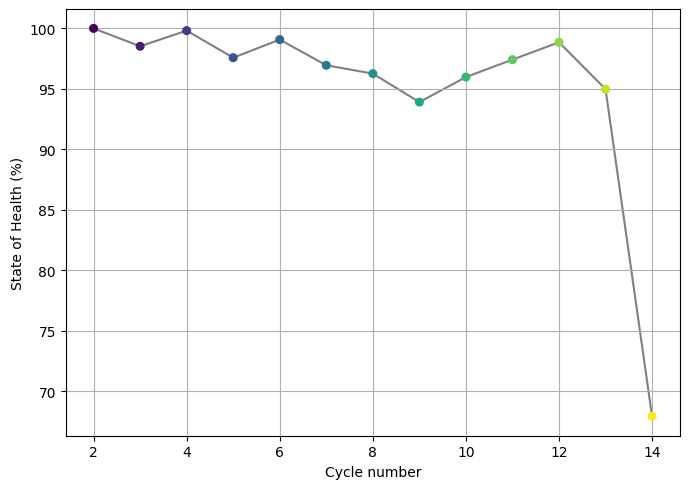

(    ciclo          qmax         soh
 0       2  23160.416263  100.000000
 1       3  22818.248997   98.522620
 2       4  23117.922709   99.816525
 3       5  22599.596322   97.578541
 4       6  22945.803733   99.073365
 5       7  22454.305891   96.951219
 6       8  22294.700388   96.262088
 7       9  21749.799512   93.909364
 8      10  22228.696371   95.977102
 9      11  22562.445989   97.418137
 10     12  22894.697279   98.852702
 11     13  21997.243361   94.977755
 12     14  15734.873053   67.938645,
 np.float64(23160.41626328548),
 2)

In [53]:
pl.plot_soh(
    dict_ciclos_sep,
    ciclos_sel_todos,
    nombre_dataset, 
    Path('../tmp')
)

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


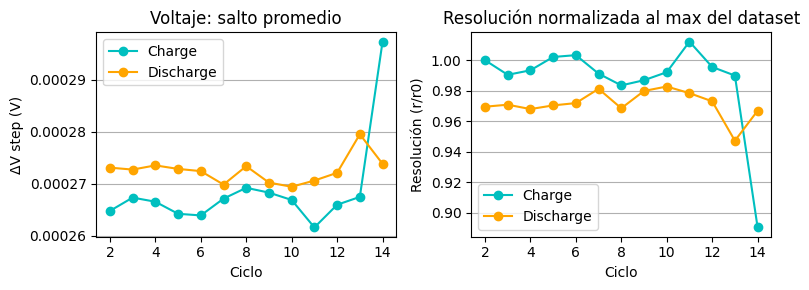

Puntos promedio por ventana de 2 mV:


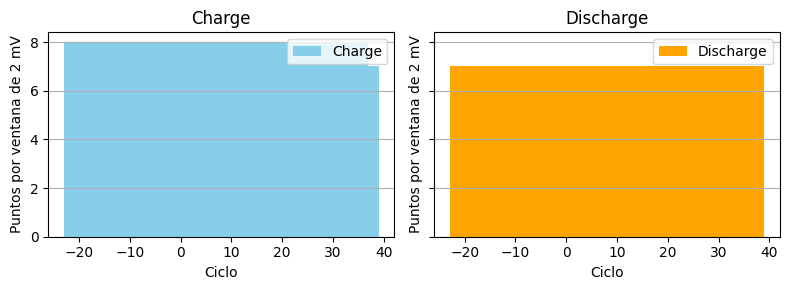

In [54]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_sep)

#utl.resolucion_Q(ciclos_sel_todos, dict_ciclos_sep)

## Pruebo parametros filtros para calcular derivada

In [70]:
import matplotlib.pyplot as plt

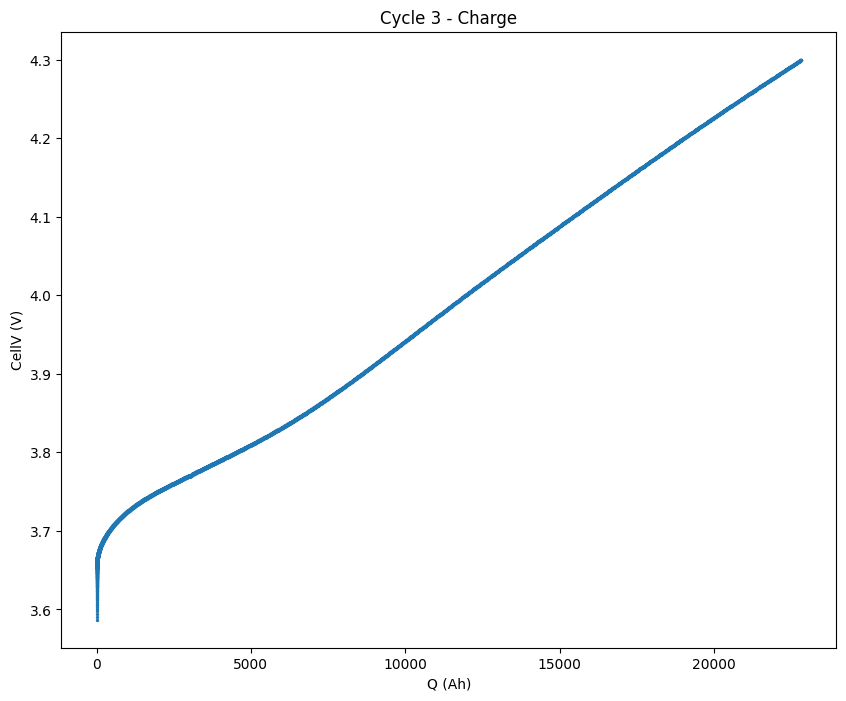

In [88]:
voltage = dict_ciclos_sep[3]['Ch']['CellV'][26:]  # trunco los primeros 20 puntos ruidosos
Q = dict_ciclos_sep[3]['Ch']['Q'][26:]

plt.figure(figsize=(10, 8))
plt.scatter(Q, voltage, s=2)
plt.xlabel('Q (Ah)')
plt.ylabel('CellV (V)')
plt.title('Cycle 3 - Charge')
#plt.xlim(0,50)
plt.show()

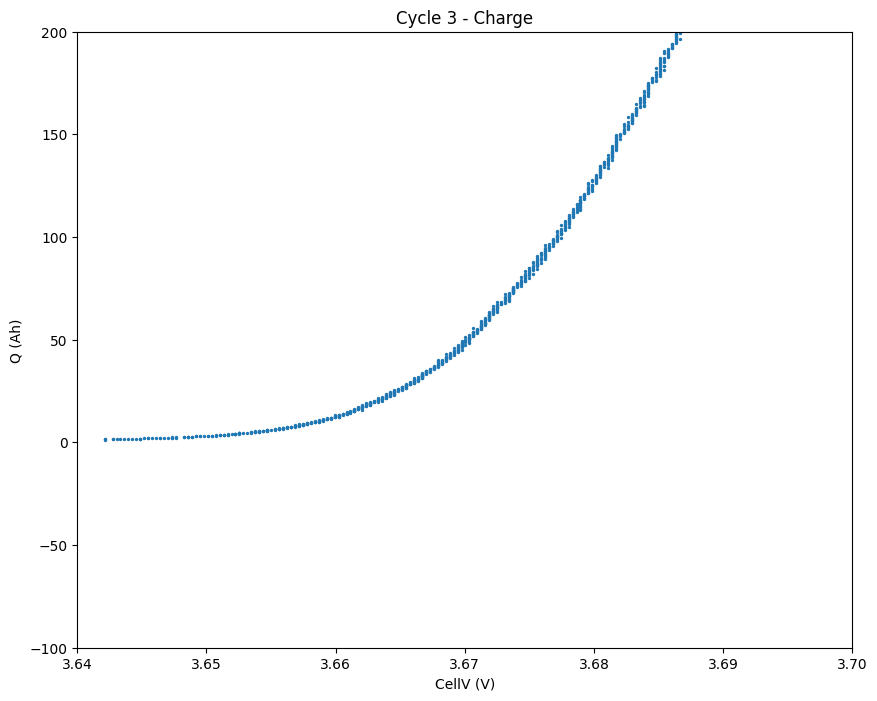

In [105]:
voltage = dict_ciclos_sep[3]['Ch']['CellV'][80:]  # trunco los primeros 20 puntos ruidosos
Q = dict_ciclos_sep[3]['Ch']['Q'][80:]

plt.figure(figsize=(10, 8))
plt.scatter(voltage, Q, s=2)
plt.xlabel('CellV (V)')
plt.ylabel('Q (Ah)')
plt.title('Cycle 3 - Charge')
plt.xlim(3.64,3.7)
plt.ylim(-100,200)
plt.show()

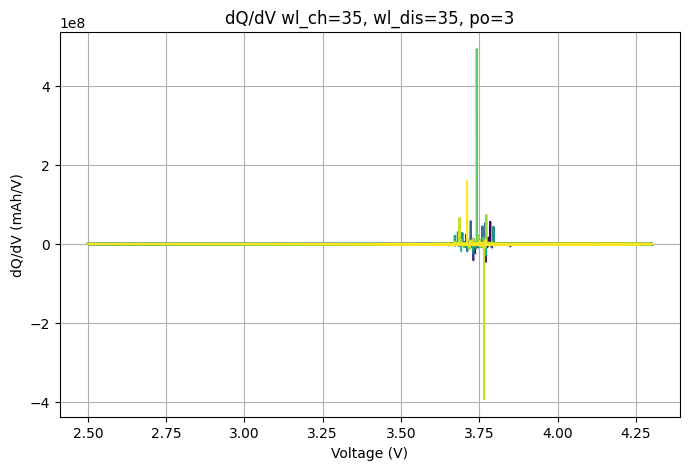

In [99]:
diccio_todos = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_sep.items()}
diccio_todos = dr.truncar_señal(ciclos_sel_todos, diccio_todos, n_dis=60, n_ch=60)
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=35, wl_ch=35)


/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_fun

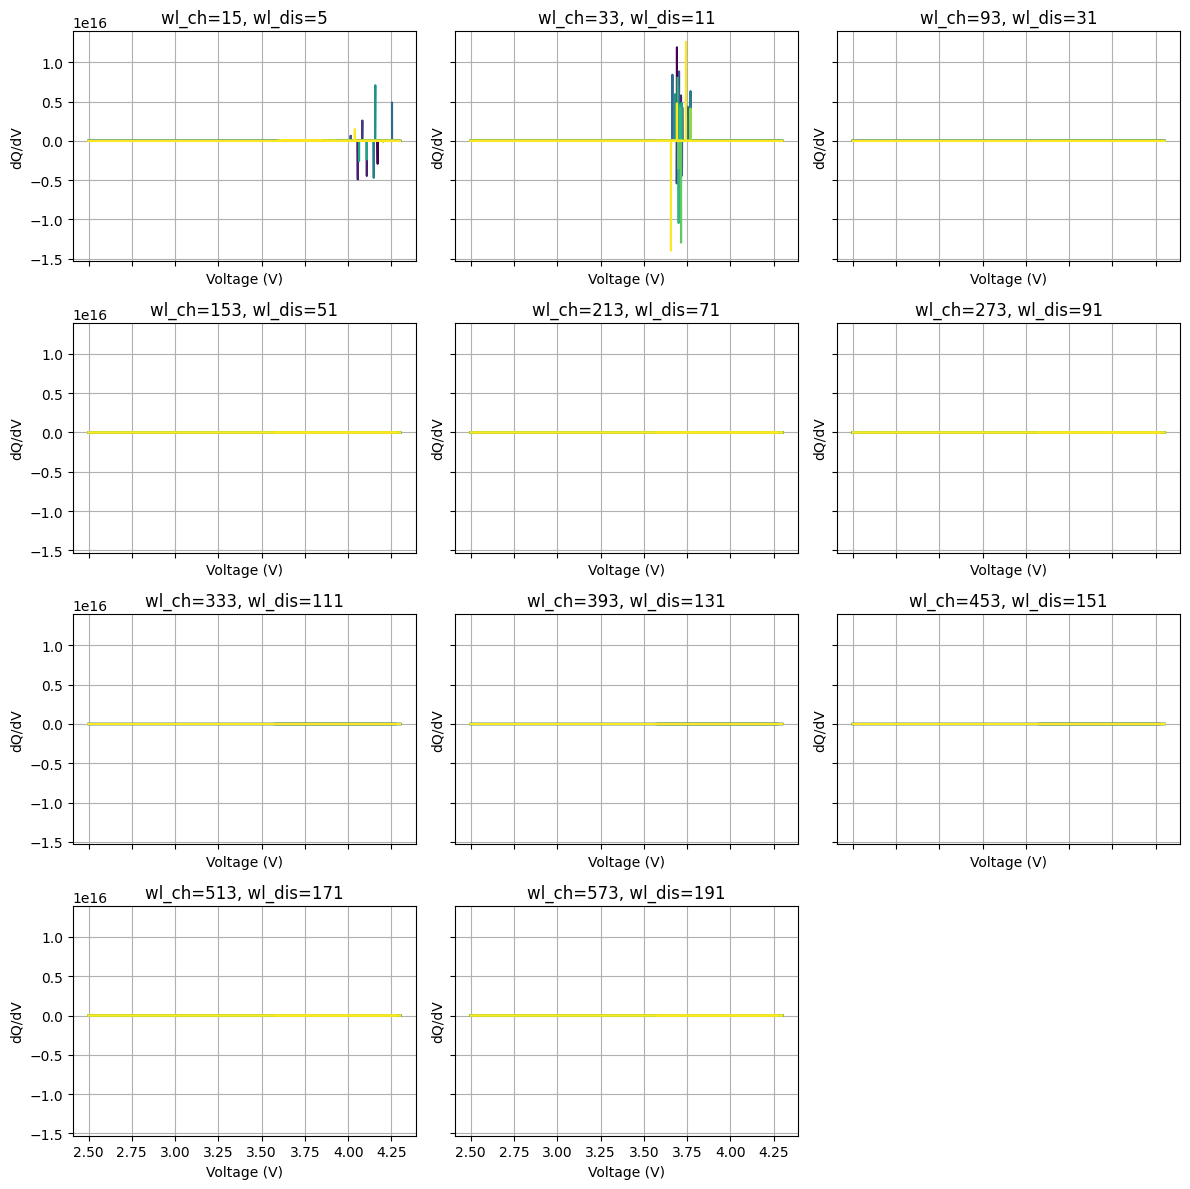

In [76]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_sep, wl_values=[5,11,31,51,71,91,111,131,151,171,191], truncar_values=(25,25))

## Calculo derivada con los parámetros dados

> En este conjunto de datos, la señal de carga tiene **3 veces más resolución** que la de descarga.  
> Estos valores pueden cambiar según el dataset.  
>  
> **NMC-20**  
> • Carga: ventana = **153**, truncar **30** puntos iniciales  
> • Descarga: ventana = **51** (153/3), truncar **10** puntos finales (30/3)  
>  
> **NMC-10**  
> • Carga: ventana = **213**, truncar **30** puntos iniciales  
> • Descarga: ventana = **71**, truncar **10** puntos finales  

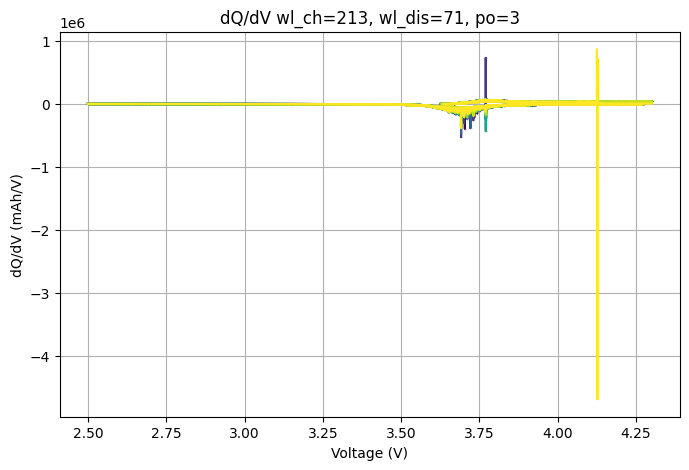

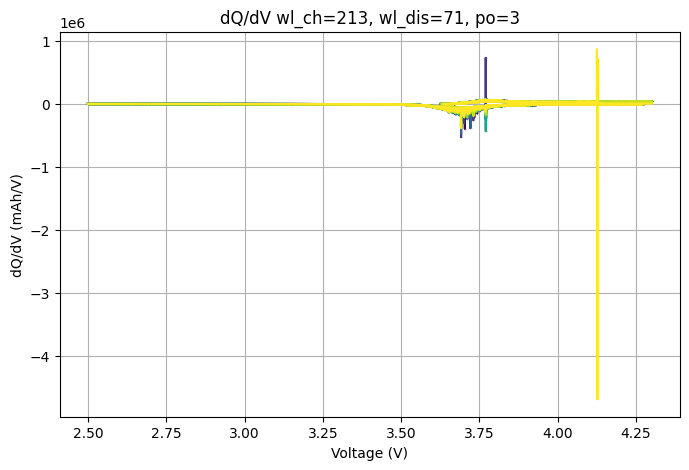

In [56]:
# --- Trunco datos y calculo derivada ---

diccio_grafico = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()}  for ciclo, df in dict_ciclos_sep.items()}
diccio_grafico = dr.truncar_señal(ciclos_sel_grafico, diccio_grafico, n_dis=20, n_ch=60)
diccio_grafico =  dr.plot_dqdV(ciclos_sel_grafico, diccio_grafico, wl_dis=71, wl_ch=213)

diccio_todos = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_sep.items()}
diccio_todos = dr.truncar_señal(ciclos_sel_todos, diccio_todos, n_dis=20, n_ch=60)
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=71, wl_ch=213)

# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)